In [2]:
# =========================================================================
# 설비 이상감지 + 원인분류 실습 
#
# 분석 프로세스
# 1) 정상/이상 설비 데이터 생성
# 2) 주요 영향인자 선정
# 3) 설비 특성 기반 파생변수(치명인자) 생성
# 4) 최적 Indicator 선정
# 5) 치명인자 관계 영향도 그래프 확인
# 6) 머신러닝 기반의 Warning / Critical Threshold 기준 정의
# 7) 이상 원인 진단 분류
# 8) 신규 데이터 이상감지 및 원인분류 테스트
# 9) 도메인 기반 결과 해석
# =========================================================================


In [3]:
! pip install networkx

In [4]:
# -------------------------------------------------
# 1. 기본 라이브러리 Import
# -------------------------------------------------

import numpy as np                           # 수치 계산을 위한 라이브러리
import pandas as pd                          # 표 형태 데이터 처리를 위한 라이브러리
import matplotlib.pyplot as plt              # 그래프 시각화 처리를 위한 라이브러리
import seaborn as sns                        # 그래프 시각화                       
import networkx as nx                        # 변수 간 관계 그래프를 그리기 위한 라이브러리

from sklearn.model_selection import train_test_split                # 학습/검증 데이터 분리 함수
from sklearn.preprocessing import StandardScaler                    # 변수 스케일 표준화를 위한 클래스
from sklearn.ensemble import RandomForestClassifier                 # 원인분류 모델로 사용할 랜덤포레스트
from sklearn.ensemble import IsolationForest                        # 비지도 이상감지 모델
from sklearn.metrics import classification_report                   # 분류 성능 리포트 출력
from sklearn.metrics import confusion_matrix                        # 혼동행렬 계산 함수
from sklearn.metrics import roc_curve                               # ROC 기반 threshold 탐색
from sklearn.metrics import roc_auc_score                           # 이상 감지 성능 AUC 계산 함수
from sklearn.inspection import permutation_importance               # 변수 중요도 검증 함수
from sklearn.feature_selection import mutual_info_classif           # 변수와 이상 여부 간 비선형 관련성 계산  

import warnings                                                     # 불필요한 경고 제거
warnings.filterwarnings("ignore")

np.random.seed(42)

In [5]:
# -------------------------------------------------
# 2. 설비 데이터 생성 함수
# -------------------------------------------------

def generate_machine_data(n_normal=5000, n_abnormal_each=1000):
    # 정상 데이터 5000개 생성
    # 고장 유형별로 이상 데이터를 1000개씩 생성

    rows= []     # 생성된 데이터를 저장할 빈 리스트 생성
    fault_type = ["normal", "bearing_wear", "lubrication_fault", "hydraulic_leak"]
    '''
    1. bearing_wear
    -원인 : 부적절한 윤활, 먼지, 금속입자 등 오염물질 유입, 과도한 하중, 부식
    -증상 : 기계 작동 시, 평소와 다른 소음 발생, 과도한 진동, 부품의 발열 및 효율 저하

    2, lubrication_fault
    -원인 : 누유, 씰 또는 오링의 노상 마모 및 파손으로 인해 오일이 외부로 새어 나가는 경우 및 또는 이물질 혼입
    -증상 : 마찰에 의한 이상 소음 및 진동, 발열, 마모 및 분진 발생

    3. hydraulic_leak
    -원인 : 마모 및 노후화 - 고압의 기름을 전달하는 호스가 찢어지거나 연결 부위의 고무 씰이 닳았을 때 발생
    -증상 : 진동 및 과열, 실린더/프레스 등 성능 저하, 모터 과부하, 설비 소음 및 진동 발생, 발열 발생
    '''

    # 정상과 고장 유형의 이름 데이터 범위 정의
    for fault in fault_type:
        # 정상과 각 고장 유형에 대해 반복 수행
        if fault == "normal":
            n = n_normal                     # 정상 데이터 개수
        else:
            n = n_abnormal_each              # 이상 데이터 개수

        for i in range(n):   # 각 센서를 하나씩 생성
            rpm = np.random.normal(1500, 40)
            # 설비 회전수 생성 : 정상 기준 평균 1500 rpm, 표준편차 40

            load = np.random.normal(65, 8)
            # 설비 부하율 생성 : 정상 기준 평균 65, 표준편차 8

            pressure = np.random.normal(120, 5)
            # 유압 압력 생성 : 정상 기준 평균 120 bar, 표준편차 5

            temp = np.random.normal(55, 3)
            # 베어링 또는 구동부 온도 생성 : 정상 기준 평균 55도, 표준편차 3

            vibration = np.random.normal(1.2, 0.2)
            # 진동 RMS 생성 : 정상 기준 평균 1.2, 표준편차 0.2

            current = np.random.normal(22, 2)
            # 모터 전류 생성 : 정상 기준 평균 22A, 표준편차 2

            oil_viscosity = np.random.normal(42, 3)
            # 윤활유 점도 생성 : 정상 기준 평균 42 cSt, 표준편차 3

            flow_rate = np.random.normal(80, 5)
            # 유량 생성 : 정상 기준 평균 80 L/min, 표준편차 5

            noise_1 = np.random.normal(0, 1)
            # 의미 없는 랜덤 변수 1 생성

            noise_2 = np.random.normal(10, 5)
            # 의미 없는 랜덤 변수 2 생성

            noise_3 = np.random.normal(0, 100)
            # 의미 없는 랜덤 변수 3 생성

            if fault == "bearing_wear":
                # 베어링 마모 고장 조건
                vibration += np.random.normal(1.2, 0.25)  # 베어링 마모시 진동이 증가함

                temp += np.random.normal(8, 2)            # 베어링 마모시 마찰열로 온도가 증가함

                current += np.random.normal(3,1)          # 마찰 증가로 모토 전류가 증가함

            elif fault == "lubrication_fault":
                # 윤활 불량 고장 조건
                oil_viscosity -= np.random.normal(12, 2)    # 윤활유 점도가 낮아짐

                temp += np.random.normal(10, 2)             # 윤활 불량으로 온도가 증가함

                vibration += np.random.normal(0.7, 0.2)     # 윤활 불량으로 진동이 증가함

                current += np.random.normal(2, 0.8)         # 마찰 증가로 모토 전류가 증가함

            elif fault == "hydraulic_leak":
                # 유압 누설 고장 조건
                pressure -= np.random.normal(25, 4)         # 누설로 인해 압력이 감소함

                flow_rate -= np.random.normal(18, 4)        # 누설 또는 효율 저하로 유량이 감소함

                current += np.random.normal(1.5, 0.6)       # 보상 운전으로 전류가 증가함

                load -= np.random.normal(5, 2)              # 유압 효율 저하로 실제 부하 전달력이 낮아짐


            if fault == "normal":
                is_abnormal = 0            # 정상 데이터는 0으로 표시

            else:
                is_abnormal = 1            # 이상 데이터는 1로 표시


            rows.append([                  # 하나의 샘플을 리스트에 추가
                rpm,
                load,
                pressure,
                temp,
                vibration,
                current,
                oil_viscosity,
                flow_rate,
                noise_1,
                noise_2,
                noise_3,
                is_abnormal,
                fault
            ])

    columns = [     # 데이터프레임 컬럼 이름 정의
        "rpm",
        "load",
        "pressure",
        "temp",
        "vibration",
        "current",
        "oil_viscosity",
        "flow_rate",
        "noise_1",
        "noise_2",
        "noise_3",
        "is_abnormal",
        "fault_type"
    ]

    df = pd.DataFrame(rows, columns=columns)    # 리스트 데이터를 DataFrame으로 변환

    return df           


In [6]:
# -------------------------------------------------
# 3. 데이터 생성
# -------------------------------------------------

df = generate_machine_data()   # 설비 정상/이상 데이터 생성

df.head()    # 상위 데이터 5개 확인

,rpm,load,pressure,temp,vibration,current,oil_viscosity,flow_rate,noise_1,noise_2,noise_3,is_abnormal,fault_type
0,1519.868566,63.893886,123.238443,59.569090,1.153169,21.531726,46.737638,83.837174,-0.469474,12.712800,-46.341769,0,normal
1,1481.370810,66.935698,110.433599,49.825247,1.087542,19.974338,42.942742,75.459880,-1.412304,17.328244,-22.577630,0,normal
2,1502.701128,53.602015,117.278086,55.332768,0.969801,22.751396,40.198084,78.541531,-0.601707,19.261391,-1.349722,0,normal
3,1457.691563,71.580359,113.895782,55.626591,0.808066,19.343628,42.590584,83.692333,0.171368,9.421759,-30.110370,0,normal
4,1440.859120,59.241246,117.696806,58.171367,1.268724,18.473920,42.972252,78.074589,-0.676922,13.058381,103.099952,0,normal


In [7]:
# 고장 유형별 데이터 개수 확인
df["fault_type"].value_counts()

fault_type
normal               5000
bearing_wear         1000
lubrication_fault    1000
hydraulic_leak       1000
Name: count, dtype: int64

In [10]:
# -------------------------------------------------
# 4. 주요 영향인자 선정 
# -------------------------------------------------

# row 데이터 변수 목록 정의
sensor_cols =[
    "rpm",
    "load",
    "pressure",
    "temp",
    "vibration",
    "current",
    "oil_viscosity",
    "flow_rate",
    "noise_1",
    "noise_2",
    "noise_3"
]

X_sensor = df[sensor_cols]   # 센서 변수만 입력 데이터로 선택

y_abnormal = df["is_abnormal"]    # 정상/이상 라벨 선택


## 1) 상관계수, 2) mutual information, 3) 랜덤포레스트 3가지의 중요도로 확인

# 1) x, y 간의 상관관계 판단
corr_result = df[sensor_cols + ["is_abnormal"]].corr()["is_abnormal"].abs().sort_values(ascending=False)
# 각 센서 변수와 이상 여부 간 상관계수 절댓값 계산 <-- 고장과의 선형관계 확인(영향도)   예) 온도 상승 --> 고장

# 2) x, y 간의 비선형 관계 판단
mi_scores = mutual_info_classif(X_sensor, y_abnormal, random_state=42)
# 각 센서 변수와 이상 여부 간 비선형 정보량 계산
# 비선형을 확인 이유는 고장은 상승, 급감소의 상태도 있기때문에 비선형으로도 확인 필요)
# 예) 온도 상승 --> 고장 / 온도 급감소 --> 고장

mi_result = pd.Series(mi_scores, index=sensor_cols).sort_values(ascending=False)
# 결과를 보기 좋게 series 형태로 변환

# 3) rf 모델 예측 기여도 판단
rf_for_importance = RandomForestClassifier(n_estimators=300, random_state=42)   # 변수 중요도 계산을 위한 RF 모델 생성

rf_for_importance.fit(X_sensor, y_abnormal)    # 랜던포레스트 기반 row 센서 정상/이상 분류 모델 학습

rf_importance = pd.Series(rf_for_importance.feature_importances_, index=sensor_cols).sort_values(ascending=False)
# 랜덤포레스 모델 기반 변수 중요도 계산  <-- 잘 예측했다면 변수들은 중요도가 높다고 판단

# 상관계수, mutual information, 랜던포레스트 중요도 결과를 dataframe으로 통합
importance_df = pd.DataFrame({        
    "corr_abs": corr_result.drop("is_abnormal"),
    "mutual_info": mi_result,
    "rf_importance": rf_importance
})

# 세가지 기준의 순위를 합산하여 종합 점수 계산
importance_df["total_score"] = (
    importance_df["corr_abs"].rank(ascending=True) +
    importance_df["mutual_info"].rank(ascending=True) +
    importance_df["rf_importance"].rank(ascending=True)
)

importance_df = importance_df.sort_values("total_score", ascending=False)   # 종합 점수가 높은 순서대로 정렬

importance_df  

,corr_abs,mutual_info,rf_importance,total_score
vibration,0.624287,0.266702,0.341067,33.0
temp,0.574843,0.232467,0.187249,29.0
pressure,0.407246,0.126825,0.217685,27.0
current,0.459421,0.123947,0.041157,23.0
flow_rate,0.371761,0.115161,0.117143,21.0
oil_viscosity,0.384970,0.106068,0.077990,20.0
load,0.090791,0.006220,0.004916,15.0
noise_3,0.007961,0.005287,0.003418,11.0
noise_2,0.013978,0.000000,0.003096,8.0
rpm,0.000074,0.000000,0.003298,6.0


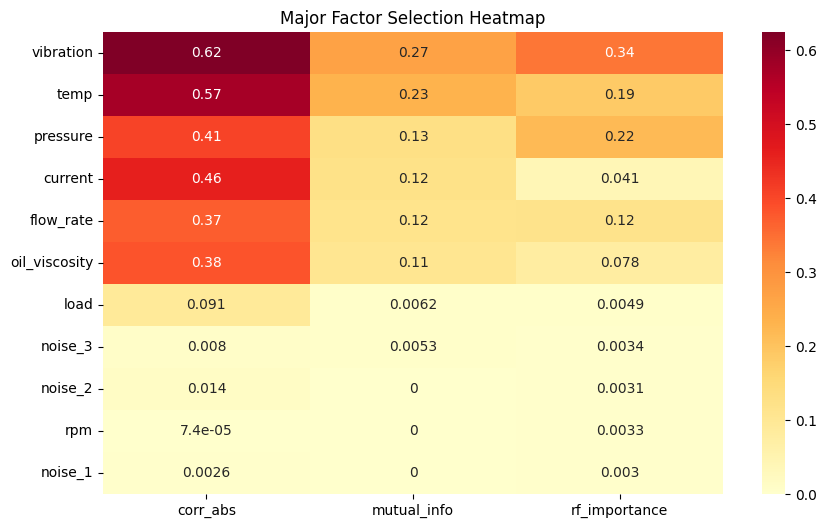

In [11]:
# -------------------------------------------------
# 7. 주요 영향인자 히트맵 시각화 
# -------------------------------------------------
plt.figure(figsize=(10,6))

# 영향 인자 점수를 히트맵으로 표현
sns.heatmap(
    importance_df[["corr_abs", "mutual_info", "rf_importance"]],
    annot=True,
    cmap="YlOrRd"
)
plt.title("Major Factor Selection Heatmap")
plt.show()



In [12]:
# ----------------------------------------------------
# 6. 설비 특성 기반의 파생변수(치명인자) 생성 (row 기준) 
# ----------------------------------------------------

def add_critical_features(df):

    df = df.copy()   # 원본 보호하기 위해 복사본 생성

    # 1. 열-전류 스트레스 지수 생성
    df["thermal_stress_index"] = df["temp"] * df["current"] / (df["rpm"] + 1)
    # --> 온도와 전류가 높고, 회전수가 낮으면 부하성 열화 가능성이 높다고 판단

    # 2. 진동-부하 결합 지수 생성
    df["vibration_load_index"] = df["vibration"] * df["load"]
    # --> 부하가 높은 상태에서 진동이 크면 베이링/구동계 이상 가능성이 커진다고 판단

    # 3. 유압 효율 지수 생성
    df["hydraulic_efficiency_index"] = df["pressure"] * df["flow_rate"] / (df["current"] +1)
    # --> 같은 전류가 나오는데, 압력과 유량이 낮으면 효율 저하 가능성이 있다고 판단

    # 4. 윤활 열화 지수 생성
    df["lubrication_degradation_index"] = df["temp"] / (df["oil_viscosity"] + 1)
    # --> 온도가 높고, 점도가 낮으면 윤활 불량 가능성이 높다고 판단

    # 5.압력-유량 균형 지수 생성
    df["pressure_flow_balance"] = df["pressure"] / (df["flow_rate"] +1)
    # --> 유압 시스템에서 압력과 유량의 비정상 관계를 확인하기 위한 지표

    # 6. 기계 마찰 지수 생성
    df["mechanical_friction_index"] = df["current"] * df["vibration"] / (df["load"] + 1)
    # --> 전류와 진동이 동시에 높으면 마찰 또는 정렬 불량 가능성이 있다고 판단

    # 7. 에너지 손실 지수 생성
    df["energy_loss_index"] = df["current"] / (df["pressure"] + 1)
    # --> 전류는 높은데 압력이 낮으면 에너지 손실 또는 누설 가능성이 있다고 판단

    return df

df_feat = add_critical_features(df)   # 파생변수 추가한 dataframe

critical_cols = [
    "thermal_stress_index",
    "vibration_load_index",
    "hydraulic_efficiency_index",
    "lubrication_degradation_index",
    "pressure_flow_balance",
    "mechanical_friction_index",
    "energy_loss_index"
]

df_feat.head()   

    
    


,rpm,load,pressure,temp,vibration,current,oil_viscosity,flow_rate,noise_1,noise_2,noise_3,is_abnormal,fault_type,thermal_stress_index,vibration_load_index,hydraulic_efficiency_index,lubrication_degradation_index,pressure_flow_balance,mechanical_friction_index,energy_loss_index
0,1519.868566,63.893886,123.238443,59.569090,1.153169,21.531726,46.737638,83.837174,-0.469474,12.712800,-46.341769,0,normal,0.843351,73.680469,458.551763,1.247843,1.452647,0.382620,0.173310
1,1481.370810,66.935698,110.433599,49.825247,1.087542,19.974338,42.942742,75.459880,-1.412304,17.328244,-22.577630,0,normal,0.671375,72.795416,397.309615,1.133867,1.444334,0.319757,0.179249
2,1502.701128,53.602015,117.278086,55.332768,0.969801,22.751396,40.198084,78.541531,-0.601707,19.261391,-1.349722,0,normal,0.837199,51.983303,387.817224,1.343091,1.474426,0.404094,0.192355
3,1457.691563,71.580359,113.895782,55.626591,0.808066,19.343628,42.590584,83.692333,0.171368,9.421759,-30.110370,0,normal,0.737661,57.841653,468.559675,1.276115,1.344818,0.215360,0.168358
4,1440.859120,59.241246,117.696806,58.171367,1.268724,18.473920,42.972252,78.074589,-0.676922,13.058381,103.099952,0,normal,0.745325,75.160771,471.868523,1.322911,1.488428,0.389074,0.155640


In [13]:
df_feat.columns

Index(['rpm', 'load', 'pressure', 'temp', 'vibration', 'current',
       'oil_viscosity', 'flow_rate', 'noise_1', 'noise_2', 'noise_3',
       'is_abnormal', 'fault_type', 'thermal_stress_index',
       'vibration_load_index', 'hydraulic_efficiency_index',
       'lubrication_degradation_index', 'pressure_flow_balance',
       'mechanical_friction_index', 'energy_loss_index'],
      dtype='object')

hydraulic_efficiency_index       0.219962
mechanical_friction_index        0.205341
energy_loss_index                0.156548
vibration_load_index             0.150639
thermal_stress_index             0.143821
lubrication_degradation_index    0.113284
pressure_flow_balance            0.010405
dtype: float64


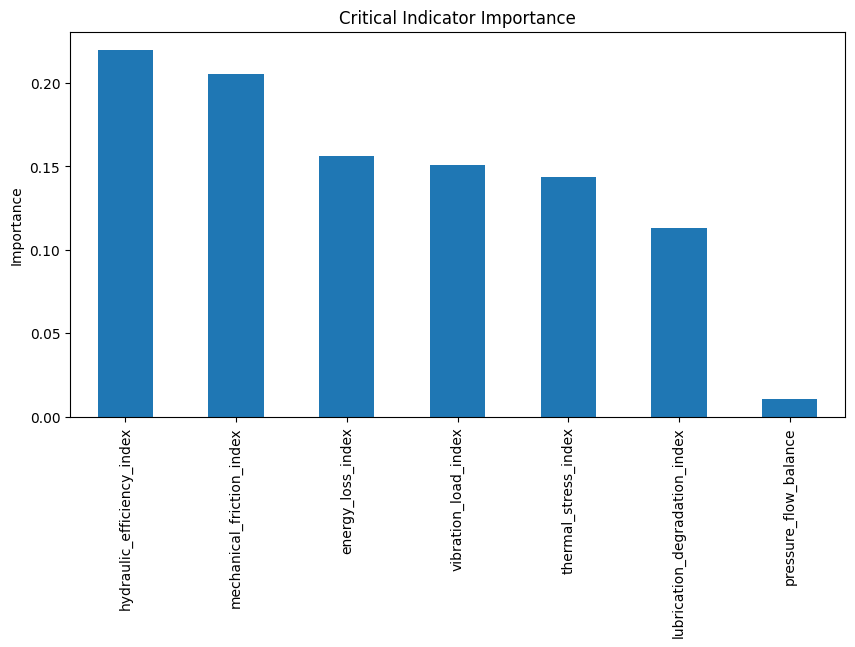

In [14]:
# ----------------------------------------------------
# 7. 최적 Indicator 선정 
# ----------------------------------------------------

X_critical = df_feat[critical_cols]    # x : 파생변수 인자만 입력 변수로 선택

rf_indicator = RandomForestClassifier(n_estimators=300, random_state=42)  # indicator 모델 생성

rf_indicator.fit(X_critical, y_abnormal)    # 파생변수로 정상/이상 분류 모델 학습

# 파생 변수에 대한 중요도 계산
indicator_importance = pd.Series(
    rf_indicator.feature_importances_,
    index=critical_cols
).sort_values(ascending=False)    

print(indicator_importance)   # 치명인자 중요도 출력

plt.figure(figsize=(10,5))
indicator_importance.plot(kind="bar")
plt.title("Critical Indicator Importance")

plt.ylabel("Importance")
plt.show()





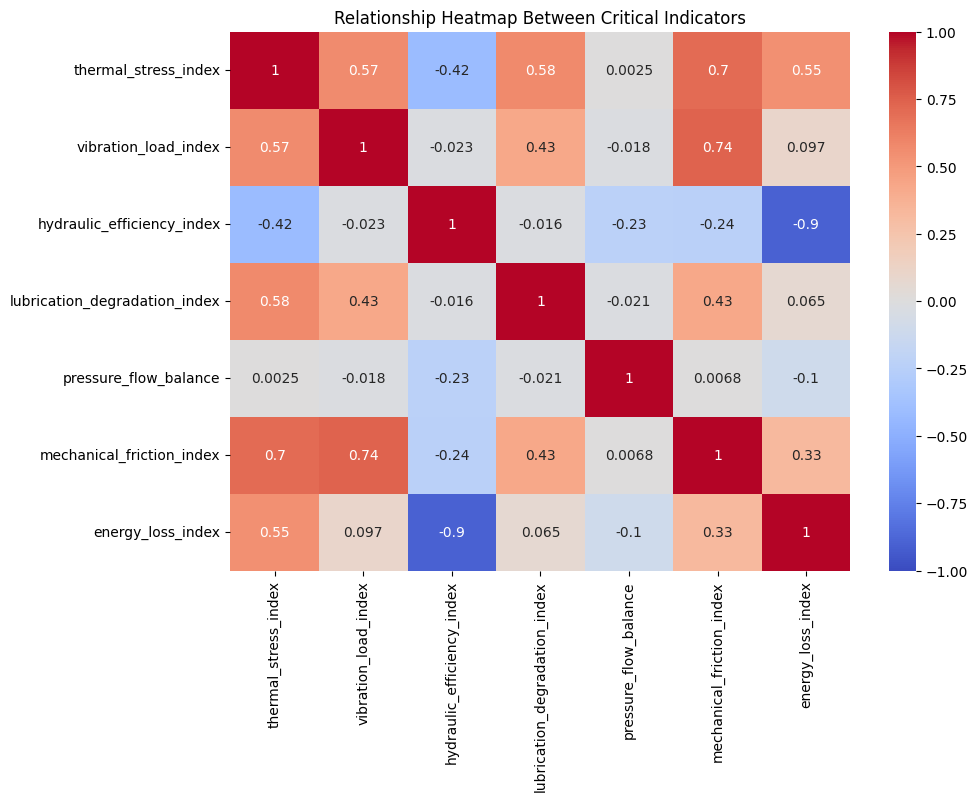

In [15]:
# ----------------------------------------------------
# 8. 치명인자 간 관계 영향도 그래프 
# ----------------------------------------------------

# 1) 히트맵
critical_corr = df_feat[critical_cols].corr()   # 치명인자 간 상관계수 계산

plt.figure(figsize=(10,7))

sns.heatmap(
    critical_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Relationship Heatmap Between Critical Indicators")

plt.show()


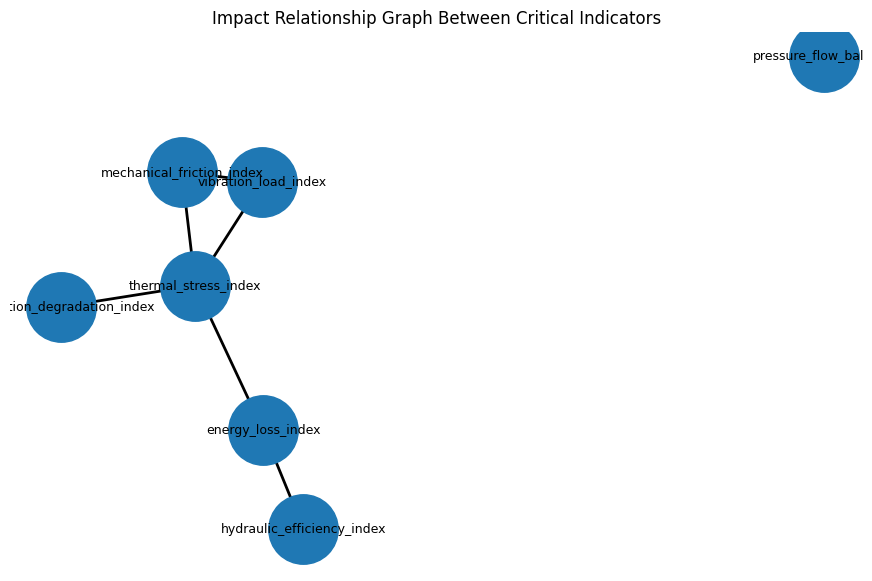

In [16]:
# 치명인자간 얼마나 강하게 연결되어 있는가를 보여주는 네트워크 그래프

G = nx.Graph()   # 변수 간 관계 그래프 객체 생성

for col in critical_cols:
    G.add_node(col)  # 치명인자 이름을 그래프 노드로 추가

for i in range(len(critical_cols)):
    for j in range(i + 1, len(critical_cols)):
        corr_value = critical_corr.iloc[i, j]  # 두 치명인자 간 상관계수 값 추출

        if abs(corr_value) >= 0.45:   # 상관계수 절대값이 0.45이상이면 의미 있는 관계로 판단
            G.add_edge(
                critical_cols[i],
                critical_cols[j],
                weight=abs(corr_value)
            )

plt.figure(figsize=(11,7))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=2500)   # 변수를 노드로 그리기

nx.draw_networkx_labels(G, pos, font_size=9)  # 노드 이름 표시

nx.draw_networkx_edges(G, pos, width=2)  # 노드 간 관계선 표시

plt.title("Impact Relationship Graph Between Critical Indicators")

plt.axis("off")

plt.show()          

        


In [18]:
# ----------------------------------------------------
# 9. 이상감지 모델 학습 
# ----------------------------------------------------

# 정상 데이터만 선택
normal_df = df_feat[df_feat["is_abnormal"] == 0]

# 정상 데이터에서 치명인자(파생변수)만 선택
X_normal = normal_df[critical_cols]

scaler = StandardScaler()  # 정규화 처리

X_normal_scaled = scaler.fit_transform(X_normal)   

iso_model = IsolationForest(
    n_estimators=300,    # 트리개수 300
    contamination=0.05,   # 학습 정상 데이터 중 이상치로 볼 비율
    random_state=42  
)

iso_model.fit(X_normal_scaled)    # 정상 데이터마 사용하여 이상감지 모델 학습

X_all_scaled = scaler.transform(df_feat[critical_cols])   # 전체 데이터의 치명인자를 정상 기준 스케일로 변환

raw_score = iso_model.decision_function(X_all_scaled)   
# Isolation Forest의 decision score 계산
# --> 값이 낮을 수록 이상일 가능성이 높음

df_feat["anomaly_score"] = -raw_score
# 해석을 쉽게 하기 위해 값이 클수록 이상이 되도록 부호를 반전
# --> 정상 0.10, 0.15   / 비정상 0.65, 0.85   

auc = roc_auc_score(df_feat["is_abnormal"], df_feat["anomaly_score"])
# 이상점수와 실제 이상 라벨 기준으로 auc 계산
# --> threshold를 정하지 않은 상태에서 이상점수 자체가 정상과 이상을 얼마나 잘 분리하는지 평가하는 지표    
# 정상 데이터보다 이상 데이터에 더 높은 anomaly score를 줄 확률

print("Anomlay Detection AUC : ", auc)


Anomlay Detection AUC :  0.980279


In [19]:
# ----------------------------------------------------
# 10. Warning / Critical Threshold 정의  (현장은 정상, 주의, 위험으로 표시)
# ----------------------------------------------------
'''
# Critical 
주의 또는 위험으로 표현해야함.
그래서 ROC_CURVE를 이용해서 정상과 이상을 가장 잘 구분하는 Critical Threshold를 정의

# Warning
정상 데이터 분포의 상위 5% 지점을 Warning Threshold로 정의  (정상이지만, 고장 전조 단계이므로 경고)

Normal --> Warning --> Critical  3단계 위험등급 체계를 구축

'''

# ROC 곡선을 이용하여 thresholde 후보들 계산
fpr, tpr, threshold = roc_curve(
    df_feat["is_abnormal"],
    df_feat["anomaly_score"]
)

# youden index : 민감도는 높고 가성알람은 낮은 지점을 찾기 위한 기준 (이상을 잘 찾으면서 가성알람은 적은 지점 탐색)
youden_index = tpr - fpr

# youden index가 가장 큰 threshold 위치
best_idx = np.argmax(youden_index)

# Critical 기준 threshold 설정
critical_threshold = threshold[best_idx]

'''예)
threshold    TPR     FPR    Youden
  0.5       0.95     0.40    0.55
  1.0       0.90     0.10    0.80             <--- 가장 큰 값이고, Threshold 1.0이 정상과 이상을 가장 잘 분리하는 지점이다.
  1.5       0.75     0.05    0.70
'''

normal_score = df_feat[df_feat["is_abnormal"] ==0]["anomaly_score"] # 정상 데이터의 이상점수만 선택

warning_threshold = np.percentile(normal_score, 95)   # 정상 데이터 상위 5% 지점을 warning 기준으로 설정

print("Warning Threshold:", warning_threshold)
print("Critical Threshold:", critical_threshold)

def classify_risk_level(score, warning_threshold, critical_threshold):
    # 이상점수를 입력받아서 위험 등급을 반환하는 함수
    
    if score >= critical_threshold:    # 이상점수가 critical 기준 이상이면 critical 등급 반환
        return "CRITICAL"

    elif score >= warning_threshold:    # 이상점수가 critical 기준 이상이면 critical 등급 반환
        return "WARNING"

    else:
        return "NORMAL"
        

# 전체 데이터에 대해 위험 등급 계산
df_feat["risk_level"] = df_feat["anomaly_score"].apply(
    lambda x: classify_risk_level(x, warning_threshold, critical_threshold)
)

# 위험 등급별 개수 출력
print(df_feat["risk_level"].value_counts())


Warning Threshold: 2.381051966379201e-17
Critical Threshold: -0.01768677511517014
risk_level
NORMAL      4761
CRITICAL    3239
Name: count, dtype: int64


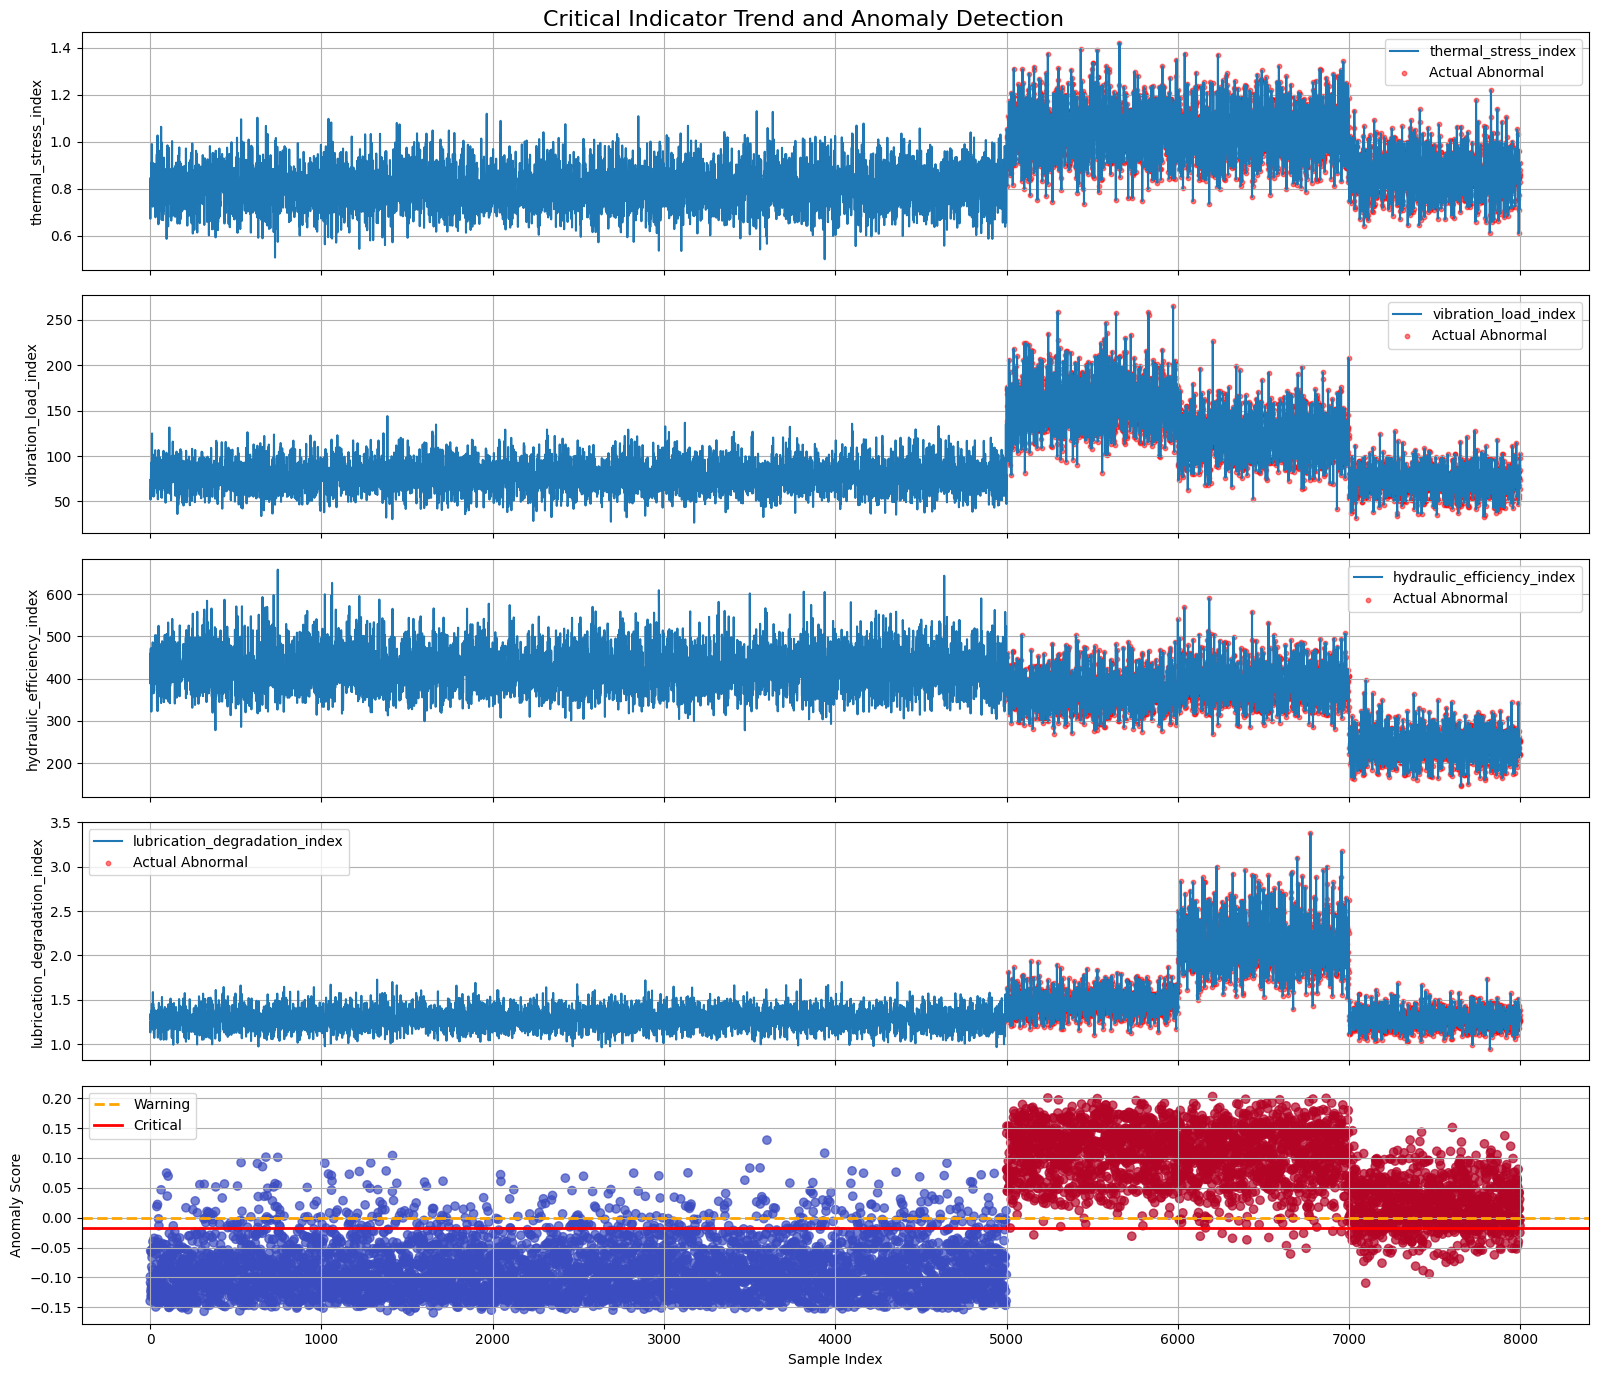

In [20]:
# ----------------------------------------------------
# 11. 이상점수를 기준으로 위험등급 생성 및 그래프 시각화
# ----------------------------------------------------

# 전체 데이터 스케일링
X_all_scaled = scaler.transform(
    df_feat[critical_cols]
)

# 이상점수 계산
raw_score = iso_model.decision_function(
    X_all_scaled
)

# anomaly score 생성
df_feat["anomaly_score"] = -raw_score

df_feat["risk_level"] = df_feat["anomaly_score"].apply(
    lambda score: classify_risk_level(
        score,
        warning_threshold,
        critical_threshold
    )
)

# anomaly score를 warning/critical 기준과 비교해서 normal, warning, critical 등급을 생성

# 치명인자 & 이상데이터 시계열 + 이상구간 비교 시각화
critical_plot_cols = [
    "thermal_stress_index",
    "vibration_load_index",
    "hydraulic_efficiency_index",
    "lubrication_degradation_index"
]

fig, axes = plt.subplots(
    len(critical_plot_cols) + 1,
    1,
    figsize=(16, 14),
    sharex=True
)

for i, col in enumerate(critical_plot_cols):
    axes[i].plot(
        df_feat.index,
        df_feat[col],
        linewidth=1.5,
        label=col
    )

    # 실제 이상 데이터 표시
    abnormal_idx = df_feat[
        df_feat["is_abnormal"] == 1
        ].index

    axes[i].scatter(
        abnormal_idx,
        df_feat.loc[abnormal_idx, col],
        color="red",
        s=10,
        alpha=0.5,
        label="Actual Abnormal"
    )

    axes[i].set_ylabel(col)
    axes[i].legend()
    axes[i].grid(True)

# 마지막 그래프 = 이상점수

axes[-1].scatter(
    df_feat.index,
    df_feat["anomaly_score"],
    c=df_feat["is_abnormal"],
    cmap="coolwarm",
    alpha=0.7
)

axes[-1].axhline(
    warning_threshold,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Warning"
)

axes[-1].axhline(
    critical_threshold,
    color="red",
    linestyle="-",
    linewidth=2,
    label="Critical"
)

axes[-1].set_ylabel("Anomaly Score")
axes[-1].legend()
axes[-1].grid(True)
axes[-1].set_xlabel("Sample Index")

plt.suptitle(
    "Critical Indicator Trend and Anomaly Detection",
    fontsize=16
)

plt.tight_layout()
plt.show()   

                   precision    recall  f1-score   support

     bearing_wear       0.98      0.98      0.98       250
   hydraulic_leak       1.00      1.00      1.00       250
lubrication_fault       0.98      0.98      0.98       250

         accuracy                           0.99       750
        macro avg       0.99      0.99      0.99       750
     weighted avg       0.99      0.99      0.99       750



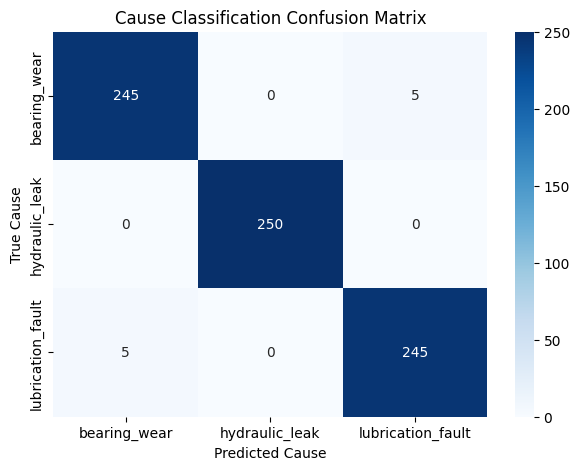

In [22]:
# ----------------------------------------------------
# 12. 원인분류 모델 학습
# ----------------------------------------------------

abnormal_df = df_feat[df_feat["is_abnormal"] == 1]  # 이상 데이터만 선택

X_cause = abnormal_df[critical_cols]                # 이상 데이터에서도 치명인자만 입력 변수로 선택

y_cause = abnormal_df["fault_type"]                 # 이상 데이터의 고장유형을 정답 라벨을 사용

X_train, X_test, y_train, y_test = train_test_split(
    X_cause,
    y_cause,
    test_size=0.25,
    random_state=42,
    stratify=y_cause
)

# 원인 분류 모델 설정 (랜덤포레스트)
cause_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    random_state=42
)

cause_model.fit(X_train, y_train)   # 원인 분류 모델 학습

y_pred = cause_model.predict(X_test)    # 학습하지 않은 X_test 데이터를 가지고 고장 원인 예측

print(classification_report(y_test, y_pred))  # 고장 원인 분류 성능 출력

cm = confusion_matrix(y_test, y_pred, labels=cause_model.classes_)  # confusion matrix 계산

plt.figure(figsize=(7,5))

# 히트맵 출력
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=cause_model.classes_,
    yticklabels=cause_model.classes_,
    cmap="Blues"
)

plt.title("Cause Classification Confusion Matrix")
plt.xlabel("Predicted Cause")
plt.ylabel("True Cause")

plt.show()


lubrication_degradation_index    0.372092
hydraulic_efficiency_index       0.197321
vibration_load_index             0.186139
mechanical_friction_index        0.131455
energy_loss_index                0.052106
thermal_stress_index             0.050267
pressure_flow_balance            0.010620
dtype: float64


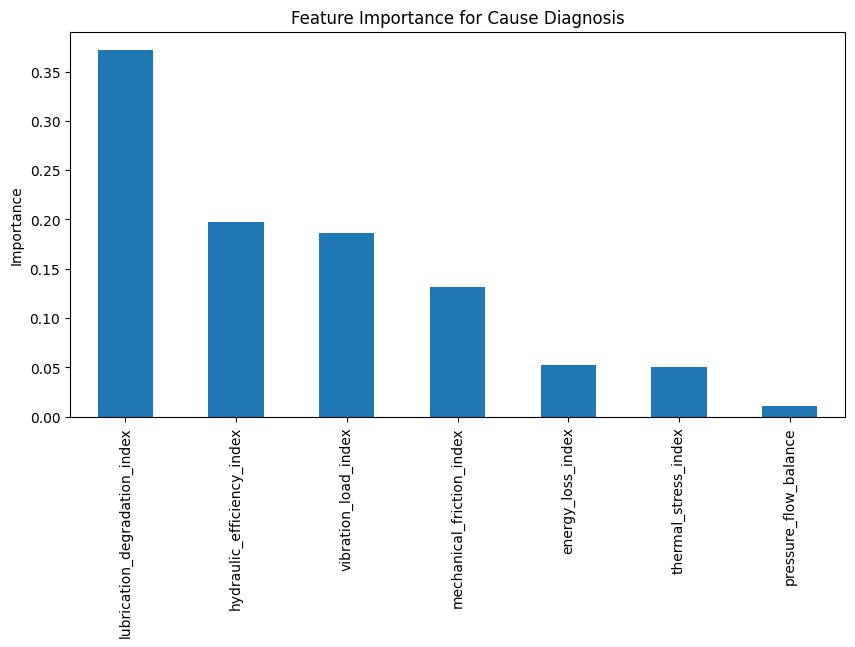

In [23]:
# ----------------------------------------------------
# 13. 원인분류 변수 중요도 확인
# ----------------------------------------------------

# 원인분류 모델의 결과를 기반으로 변수 중요도 계산
cause_importance = pd.Series(
    cause_model.feature_importances_,
    index=critical_cols).sort_values(ascending=False)     

print(cause_importance)

plt.figure(figsize=(10,5))
cause_importance.plot(kind="bar")
plt.title("Feature Importance for Cause Diagnosis")
plt.ylabel("Importance")

plt.show()

In [24]:
# -----------------------------
# 14. 신규 데이터 생성 및 테스트
# -----------------------------

new_data = pd.DataFrame([
    {
        "rpm": 1480,
        "load": 70,
        "pressure": 118,
        "temp": 69,
        "vibration": 2.7,
        "current": 27,
        "oil_viscosity": 41,
        "flow_rate": 78,
        "noise_1": 0.2,
        "noise_2": 11,
        "noise_3": 50 
    },
    {
        "rpm": 1510,
        "load": 63,
        "pressure": 92,
        "temp": 58,
        "vibration": 1.5,
        "current": 25,
        "oil_viscosity": 43,
        "flow_rate": 60,
        "noise_1": -0.4,
        "noise_2": 9,
        "noise_3": 20 
    },
    {
        "rpm": 1495,
        "load": 67,
        "pressure": 121,
        "temp": 66,
        "vibration": 2.1,
        "current": 25,
        "oil_viscosity": 28,
        "flow_rate": 79,
        "noise_1": 0.1,
        "noise_2": 12,
        "noise_3": 700 
    }
])

# 신규 샘플데이터
# 1번 : 베어링 마모 의심
# 2번 : 유압 누설 의심
# 3번 : 윤활 불량 의심

new_feat = add_critical_features(new_data)                   # 신규 데이터에 동일한 파생변수 생성
new_scaled = scaler.transform(new_feat[critical_cols])       # 파생변수 정상기준 스케일러로 변환
new_score = -iso_model.decision_function(new_scaled)         # 신규 데이터 이상점수 계산
new_feat["anomaly_score"] = new_score                        # 신규 데이터에 이상점수 추가

new_feat["risk_level"] = new_feat["anomaly_score"].apply(
    lambda x: classify_risk_level(x, warning_threshold, critical_threshold)
)

# 신규 데이터에 위험 등급 추가
new_feat["predicted_cause"] = "normal"  # 기본값은 normal로 설정

abnormal_mask = new_feat["risk_level"] != "NORMAL"     # Warning or Critical 데이터만 원인분류 대상으로 선택

# 이상으로 판단된 신규 데이터에 대해서만 고장 원인 예측 수행
new_feat.loc[abnormal_mask, "predicted_cause"] = cause_model.predict(
    new_feat.loc[abnormal_mask, critical_cols]
)

# 최종 진단 결과 출력
print(new_feat[critical_cols + ["anomaly_score", "risk_level", "predicted_cause"]])

   thermal_stress_index  vibration_load_index  hydraulic_efficiency_index  ...  anomaly_score  risk_level    predicted_cause
0              1.257934                 189.0                  328.714286  ...       0.173083    CRITICAL       bearing_wear
1              0.959629                  94.5                  212.307692  ...       0.037749    CRITICAL     hydraulic_leak
2              1.102941                 140.7                  367.653846  ...       0.141038    CRITICAL  lubrication_fault

[3 rows x 10 columns]


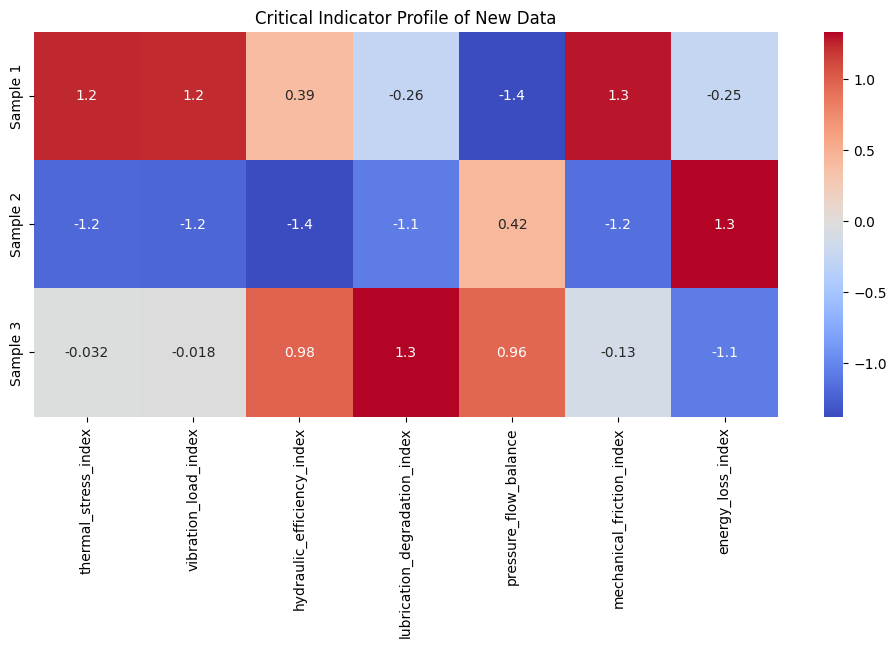

In [25]:
# -----------------------------
# 15. 신규 데이터 원인별 치명인자 프로파일 시각화
# -----------------------------

new_profile = new_feat[critical_cols].copy()   # 신규 데이터의 치명인자만 복사

new_profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(new_profile),
    columns=critical_cols
)

# 히트맵 출력
plt.figure(figsize=(12,5))
sns.heatmap(
    new_profile_scaled,
    annot=True,
    cmap="coolwarm",
    xticklabels=critical_cols,
    yticklabels=[f"Sample {i+1}" for i in range(len(new_feat))]
)

plt.title("Critical Indicator Profile of New Data")
plt.show()
